# LSTM model (Extracted Features)

**Using downsampled features**

Author: Pete King

We repeat the LSTM test with the PCA-extracted feature set, but using data downsampled to a weekly frequency.


In [1]:
#123456789012345678901234567890123456789012345678901234567890123456789012345678
import json
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import (
    make_scorer,
    r2_score,
    mean_absolute_error,
    root_mean_squared_error,
    mean_squared_error
)

import data_prep as dp
import models

# Global variables
DATA_FOLDER = 'data/downsample/W/train-val-test/'
TRAIN_DATA_FILE = DATA_FOLDER + 'train_pca_data.csv'
VAL_DATA_FILE = DATA_FOLDER + 'val_pca_data.csv'
TICKER = 'SPY'
SEQUENCE_LENGTH = 4  # No. timestamps in each input sequence to LSTM
BATCH_SIZE = 12  # For DataLoader

## I. Data Preparation

### Import and inspect financial data

In [2]:
train_df = pd.read_csv(
    TRAIN_DATA_FILE,
    index_col='date',
    parse_dates=True
)
val_df = pd.read_csv(
    VAL_DATA_FILE,
    index_col='date',
    parse_dates=True
)
# Select data (X) and label (y) -- use all features
p = re.compile(r'PCA.+')
data_cols = [col for col in train_df.columns if p.match(col) is not None]
data_cols = data_cols + [f'{TICKER}_ret-h', f'{TICKER}_vol-h']
label_col = [TICKER + '_vol_target']
train_df[data_cols].head(SEQUENCE_LENGTH)

,PCA_vol-1,PCA_vol-2,PCA_macro-1,PCA_macro-2,PCA_macro-3,PCA_macro-4,PCA_hvol-1,PCA_hvol-2,PCA_hvol-3,PCA_hvol-4,PCA_hret-1,PCA_hret-2,PCA_hret-3,SPY_ret-h,SPY_vol-h
date,,,,,,,,,,,,,,,
2015-10-11,0.019764,-0.050772,-0.084379,-0.058875,-0.067594,-0.004911,-0.073287,-0.080450,-0.077928,0.101786,0.000027,-0.092164,-0.039738,0.014307,0.009701
2015-10-18,0.140402,0.189389,0.111788,0.053244,0.164776,0.272643,0.162111,0.093840,0.019922,0.025007,-0.079395,-0.063991,-0.125502,0.008647,0.007959
2015-10-25,-0.057451,-0.121967,-0.112236,-0.080902,-0.105502,-0.113484,-0.093425,-0.139678,-0.127097,-0.027347,0.062283,0.135397,-0.058877,0.020153,0.009382
2015-11-01,-0.094880,-0.099647,-0.130287,-0.171168,-0.163077,-0.172389,-0.177274,-0.103115,-0.153335,-0.054839,-0.100587,-0.193035,-0.165150,0.004483,0.005598


In [3]:
val_df[label_col].head(SEQUENCE_LENGTH)

,SPY_vol_target
date,
2023-01-01,0.010604
2023-01-08,0.010161
2023-01-15,0.010400
2023-01-22,0.010328


### Scale Data

We represent each feature in a uniform range (0, 1).

In [4]:
scaler = MinMaxScaler()
# Take care to fit scaler only to training data
X_train = scaler.fit_transform(train_df[data_cols])
y_train = train_df[label_col].values
X_val = scaler.transform(val_df[data_cols])
y_val = val_df[label_col].values

## II. PyTorch Multivariate LSTM Model


### Create Datasets and DataLoaders

In [5]:
# Model Training
train_dataset = dp.FinancialDataset(
    X_train.astype(np.float32),
    y_train.astype(np.float32),
    sequence_length=SEQUENCE_LENGTH,
    target=True
)
train_dataloader = dp.DataLoader(
    train_dataset, batch_size=BATCH_SIZE, shuffle=False, drop_last=False
)
# Model Evaluation
val_dataset = dp.FinancialDataset(
    X_val.astype(np.float32),
    y_val.astype(np.float32),
    sequence_length=SEQUENCE_LENGTH,
    target=True
)
val_dataloader = dp.DataLoader(
    val_dataset, batch_size=BATCH_SIZE, shuffle=False, drop_last=False
)

In [6]:
# Inspect first sample and label in training dataset
X_0, y_0 = train_dataset[0]
print(f'Shape of first training sample: {X_0.shape}')
print(f'Shape of first training label: {y_0.shape}')

Shape of first training sample: torch.Size([4, 15])
Shape of first training label: torch.Size([1])


In [7]:
print(X_0)

tensor([[0.2869, 0.5657, 0.3349, 0.5826, 0.4497, 0.3302, 0.4292, 0.4006, 0.4371,
         0.7050, 0.6259, 0.3603, 0.3704, 0.4651, 0.1162],
        [0.3188, 0.6537, 0.4053, 0.6394, 0.5524, 0.4127, 0.5515, 0.4806, 0.4859,
         0.6821, 0.6036, 0.3649, 0.3560, 0.4384, 0.0928],
        [0.2664, 0.5396, 0.3249, 0.5715, 0.4329, 0.2979, 0.4187, 0.3734, 0.4125,
         0.6665, 0.6434, 0.3976, 0.3671, 0.4925, 0.1119],
        [0.2565, 0.5477, 0.3184, 0.5257, 0.4075, 0.2804, 0.3752, 0.3902, 0.3995,
         0.6583, 0.5976, 0.3437, 0.3493, 0.4189, 0.0610]])


In [8]:
# Inspect batch dimensions from dataloader
batched_data_0, batched_labels_0 = next(iter(train_dataloader))
print(f'Shape of first batch of data: {batched_data_0.shape}')
print(f'Shape of first batch of labels: {batched_labels_0.shape}')

Shape of first batch of data: torch.Size([12, 4, 15])
Shape of first batch of labels: torch.Size([12, 1])


In [9]:
print(y_0)

tensor([0.0075])


### Instantiate and train LSTM model

Here we return to a reduced hidden layer size due to the smaller set of input features.

In [10]:
## Define LSTM parameters
input_size = len(data_cols)  # Number of features in data (x)
hidden_size = 24  # Number of 'neurons' (features) in each hidden layer
num_layers = 1  # Number of LSTM layers in the model stack
batch_first = True  # Determines order of dimensions for input/output tensors
bidirectional = False  # If True, becomes a bidirectional LSTM
proj_size = 0  # If > 0, will use LSTM with projections of corresponding size

# Define variables for LSTM input/output tensor dimensions IAW PyTorch docs
N = BATCH_SIZE  # Batch size
L = SEQUENCE_LENGTH  # Sequence length (no. timestamps in rolling window)
D = int(bidirectional) + 1   # D = 1 (not birectional) or 2 (bidirectional)
H_in = input_size
H_cell = hidden_size
H_out = (proj_size if proj_size > 0 else H_in)

# Define number of dimensions in target labels (y)
label_size = len(label_col)

In [11]:
# Set an accelerator device (e.g., CUDA) if available.
if torch.accelerator.is_available():
    device = torch.accelerator.current_accelerator().type
else:
    device = 'cpu'

print(f'Device: {device}')

Device: cpu


In [12]:
# Instantiate LSTM and assign to device
model = models.FinancialLSTM(
    input_size=input_size,
    label_size=label_size,
    hidden_size=hidden_size,
    num_layers=num_layers,
    batch_first=batch_first,
    bidirectional=bidirectional,
    proj_size=proj_size
).to(device)
print(model)

FinancialLSTM(
  (lstm): LSTM(15, 24, batch_first=True)
  (fc): Linear(in_features=24, out_features=1, bias=True)
)


#### Loss function and Optimizer


In [13]:
# Define loss function and optimizer
# For multivariate loss, set parameter reduction='none'
loss_fn = torch.nn.L1Loss(reduction='mean')
optimizer = torch.optim.Adam(model.parameters())

In [14]:
# Train and evaluate model
epochs = 200
print(f'Training model over {epochs} epochs...')
for epoch in range(epochs):
    loss_trn = models.train_model(train_dataloader, model, loss_fn, optimizer)
    if (epoch + 1) % 20 == 0:
        loss_val, preds = models.evaluate_model(val_dataloader, model, loss_fn)
        print(f'Epoch {epoch + 1}')
        print(f'Training loss:   {loss_trn}')
        print(f'Validation loss: {loss_val}')

Training model over 200 epochs...
Epoch 20
Training loss:   0.0017101619159802794
Validation loss: 0.004488031379878521
Epoch 40
Training loss:   0.0020888112485408783
Validation loss: 0.005945372395217419
Epoch 60
Training loss:   0.0038458972703665495
Validation loss: 0.00023060571402311325
Epoch 80
Training loss:   0.004484132397919893
Validation loss: 0.0007596435025334358
Epoch 100
Training loss:   0.0033668624237179756
Validation loss: 0.0009631318971514702
Epoch 120
Training loss:   0.0043726759031414986
Validation loss: 0.0003584073856472969
Epoch 140
Training loss:   0.0035083533730357885
Validation loss: 0.0011047078296542168
Epoch 160
Training loss:   0.003216318553313613
Validation loss: 0.0019915131852030754
Epoch 180
Training loss:   0.003628317965194583
Validation loss: 0.0013721762225031853
Epoch 200
Training loss:   0.003036580281332135
Validation loss: 0.0026161251589655876


## III. Analyze Results

### Plot of predictions vs labels (final epoch)


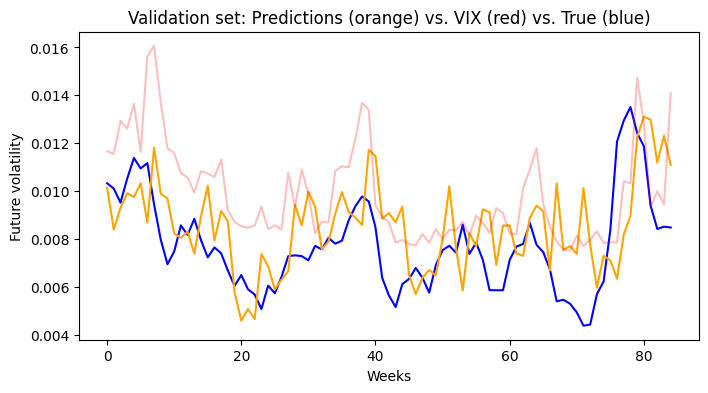

In [15]:
x = range(len(val_dataset))
labels = [val_dataset[i][1]for i in range(len(x))]
# The VIX estimates annualized volatility for the next 30 days
vix = val_df['^VIX'].values[SEQUENCE_LENGTH:] / np.sqrt(252) / 100

fig = plt.figure(figsize=(8, 4))
ax = fig.subplots()
ax.set_title('Validation set: Predictions (orange) vs. VIX (red) vs. True (blue)')
ax.set_ylabel('Future volatility')
ax.set_xlabel('Weeks')
ax.plot(x, labels, color='blue')
ax.plot(x, preds, color='orange')
ax.plot(x, vix, color='red', alpha=0.25)

The PCA features appear to help the model track much better than the full feature set, but it's not clear how much they help or hinder compared to the limited feature set.

In [16]:
metrics = {
    'MAE': mean_absolute_error,
    'R2': r2_score,
}
# Out-of-sample R-squared compares model performance to baseline (VIX)
r2_oos = 1 - (
    mean_absolute_error(labels, preds)
    / mean_absolute_error(labels, vix)
)
# Display results
for metric, scorer in metrics.items():
    print(f'Model {metric}: {scorer(labels, preds):.5f}')
    print(f'VIX {metric}:   {scorer(labels, vix):.5f}')
    print('---')
print(f'Model R2-OOS: {r2_oos:.2f}')

Model MAE: 0.00167
VIX MAE:   0.00240
---
Model R2: -0.22885
VIX R2:   -0.96082
---
Model R2-OOS: 0.30


Although it appears slower to react to market changes than the baseline model (vanilla VIX), our model achieves a lower MAE on the validation set than the baseline for this run.

Note: In conducting several runs for this LSTM model, I've noticed a significant amount of variation in the MAE score (attributable to the stochastic nature of the training process and complexity of the deep learning model).  Part of our model evaluation strategy will be to collect a distribution of MAE scores to provide a more robust comparison between models.  Sometimes we seem to get lucky during the training process and score better, other times worse than baseline.